In [1]:
#!pip install tabulate
import rasterio
import matplotlib.pyplot as plt
import numpy as np
from skimage.measure import block_reduce
import pandas as pd
import tabulate



In [2]:
##function to return zero coords##
def find_zero_coordinates(geotiff_path):
    with rasterio.open(geotiff_path) as dataset:
        data = dataset.read(1)
        
        
        zero_coords = []
        for y in range(data.shape[0]):
            for x in range(data.shape[1]):
                if data[y, x] == 0:
                    lon, lat = dataset.xy(y, x)  
                    zero_coords.append((lat, lon))
                
        
        

        return zero_coords
    



In [4]:
geotiff_path='/media/sf_Shared_Ubuntu/MAPS/GPW_2020_1deg.tif'
zero_coordinates=find_zero_coordinates(geotiff_path)
lat=[]
lon=[]
for cord in zero_coordinates:
    lat.append(cord[0])
    lon.append(cord[1])
    np.transpose(lon)


In [6]:
df = pd.DataFrame(list(zip(lon, lat)),
               columns =['Longitude', 'Latitude'])
print(df)

      Longitude  Latitude
0         -46.5      83.5
1         -45.5      83.5
2         -44.5      83.5
3         -43.5      83.5
4         -42.5      83.5
...         ...       ...
2110      179.5     -47.5
2111      178.5     -49.5
2112      -61.5     -50.5
2113      158.5     -54.5
2114      158.5     -55.5

[2115 rows x 2 columns]


In [11]:
print(np.min(lat))

-55.49999999999713


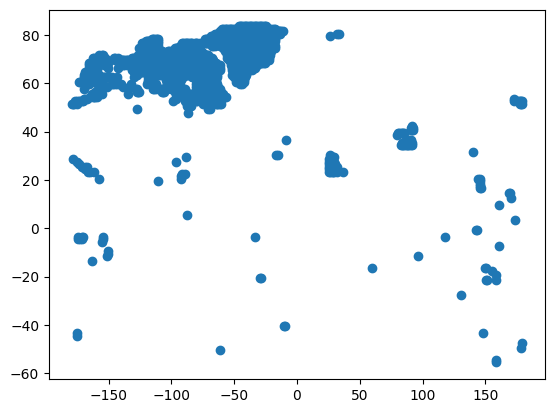

In [14]:
plt.scatter(lon,lat)